### Import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
df = pd.read_csv('Cleaned_enquiry_dataset_2020_2025.csv')

print("Shape:", df.shape)
df.head()

Shape: (1380, 20)


,Unnamed: 0,name,location,mobile_no,email,find_us,qualification,branch,career_issue,looking_for,technology,mode,time_slot,date,attended_by,no_persons,fee_details,year_of_pass_out,status,remarks
0,0,hidden,ramanattukara,hidden,hidden,google,ug,commerce,no career issue,others,data science,online,morning,11-12-2020,deepak,3,35000,2018,not joined,not impressed
1,1,hidden,kozhikode,hidden,hidden,google,ug,electronics,no career issue,work experience,mern,offline,morning,12-07-2020,lekha,2,60000,2016,not joined,not interested
2,2,hidden,nadakkavu,hidden,hidden,social media,pg,electronics,no career issue,others,java,offline,morning,26-07-2020,baiju,3,60000,2020,not joined,joined other institude
3,3,hidden,ramanattukara,hidden,hidden,social media,ug,other,non it background,short term course,python,offline,morning,18-01-2020,baiju,3,35000,2018,not joined,not interested
4,4,hidden,westhill,hidden,hidden,social media,ug,computer science,no career issue,work experience,python,online,evening,15-03-2020,rifna,5,60000,2018,not joined,not okay


In [8]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1380 non-null   int64 
 1   name              1380 non-null   object
 2   location          1380 non-null   object
 3   mobile_no         1380 non-null   object
 4   email             1380 non-null   object
 5   find_us           1380 non-null   object
 6   qualification     1380 non-null   object
 7   branch            1380 non-null   object
 8   career_issue      1380 non-null   object
 9   looking_for       1380 non-null   object
 10  technology        1380 non-null   object
 11  mode              1380 non-null   object
 12  time_slot         1380 non-null   object
 13  date              1380 non-null   object
 14  attended_by       1380 non-null   object
 15  no_persons        1380 non-null   int64 
 16  fee_details       1380 non-null   int64 
 17  

In [10]:
print("Target column value counts:")
print(df['status'].value_counts())

Target column value counts:
status
not joined    1072
joined         308
Name: count, dtype: int64


### Defining X and y

In [13]:
feature_cols = [
    'location', 'find_us', 'qualification', 'branch',
    'career_issue', 'looking_for', 'technology', 'mode',
    'time_slot', 'attended_by', 'year_of_pass_out'
]

X = df[feature_cols].copy()
y = df['status'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:")
print(X.dtypes)

X shape: (1380, 11)
y shape: (1380,)

Feature columns:
location            object
find_us             object
qualification       object
branch              object
career_issue        object
looking_for         object
technology          object
mode                object
time_slot           object
attended_by         object
year_of_pass_out     int64
dtype: object


### Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing  set size : {X_test.shape[0]} samples")

Training set size : 1104 samples
Testing  set size : 276 samples


### Label Encoding

In [18]:
categorical_cols = [
    'location', 'find_us', 'qualification', 'branch',
    'career_issue', 'looking_for', 'technology', 'mode',
    'time_slot', 'attended_by'
]

# Store encoders for reuse during prediction
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    # Fit on full column to cover all categories
    le.fit(X[col])
    X_train[col] = le.transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])
    label_encoders[col] = le

# Encode the target column
le_target = LabelEncoder()
le_target.fit(y)
y_train_enc = le_target.transform(y_train)
y_test_enc  = le_target.transform(y_test)

print("Label encoding complete.")
print(f"Target classes: {le_target.classes_}  →  {list(range(len(le_target.classes_)))}")
X_train.head()

Label encoding complete.
Target classes: ['joined' 'not joined']  →  [0, 1]


,location,find_us,qualification,branch,career_issue,looking_for,technology,mode,time_slot,attended_by,year_of_pass_out
880,11,3,4,5,2,4,2,1,0,1,2022
1025,2,4,5,2,3,0,6,0,2,1,2020
196,15,0,5,2,1,3,1,1,0,7,2018
480,5,4,0,1,3,4,1,1,1,1,2019
1085,20,1,5,0,2,4,1,1,3,1,2022


### Standardisation

In [21]:
scaler= StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Standardisation complete.")
print("X_train_scaled shape:", X_train_scaled.shape)

Standardisation complete.
X_train_scaled shape: (1104, 11)


## Model Building

#### 1. Decision Tree Classifier


In [26]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train_enc)

y_pred_dt = dt_model.predict(X_test)
print("Decision Tree — Training complete.")

Decision Tree — Training complete.


#### 2.Random Forest Classifier

In [29]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train_enc)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest — Training complete.")

Random Forest — Training complete.


#### 3. K-Nearest Neighbours (KNN)

In [32]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_enc)

y_pred_knn = knn_model.predict(X_test_scaled)
print("KNN — Training complete.")

KNN — Training complete.


#### 4. Logistic Regression

In [35]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_enc)

y_pred_lr = lr_model.predict(X_test_scaled)
print("Logistic Regression — Training complete.")

Logistic Regression — Training complete.


## Evaluation Metrics

#### 1. Decision Tree

=== Decision Tree ===
Accuracy : 0.6667

Classification Report:
              precision    recall  f1-score   support

      joined       0.27      0.29      0.28        62
  not joined       0.79      0.78      0.78       214

    accuracy                           0.67       276
   macro avg       0.53      0.53      0.53       276
weighted avg       0.67      0.67      0.67       276



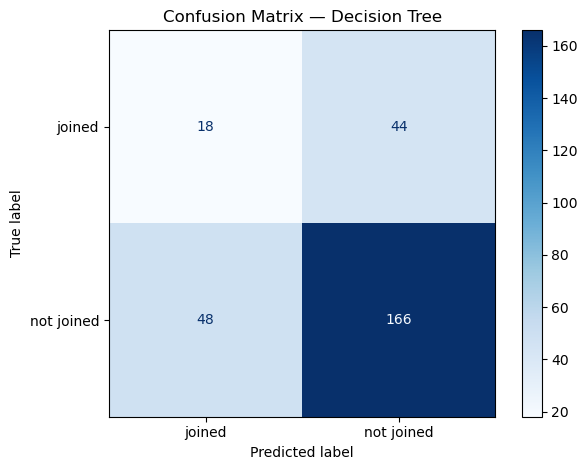

In [39]:
print("=== Decision Tree ===")
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_dt, target_names=le_target.classes_))

cm_dt = confusion_matrix(y_test_enc, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le_target.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()

#### 2. Random Forest

=== Random Forest ===
Accuracy : 0.7681

Classification Report:
              precision    recall  f1-score   support

      joined       0.00      0.00      0.00        62
  not joined       0.77      0.99      0.87       214

    accuracy                           0.77       276
   macro avg       0.39      0.50      0.43       276
weighted avg       0.60      0.77      0.67       276



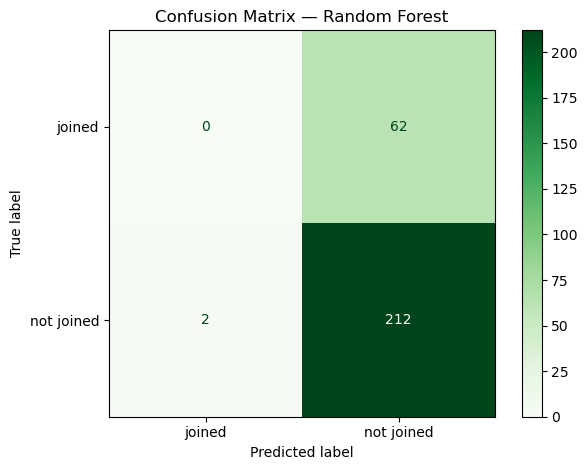

In [42]:
print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_rf, target_names=le_target.classes_))

cm_rf = confusion_matrix(y_test_enc, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le_target.classes_)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

#### 3. KNN

=== K-Nearest Neighbours ===
Accuracy : 0.7572

Classification Report:
              precision    recall  f1-score   support

      joined       0.35      0.10      0.15        62
  not joined       0.78      0.95      0.86       214

    accuracy                           0.76       276
   macro avg       0.57      0.52      0.51       276
weighted avg       0.69      0.76      0.70       276



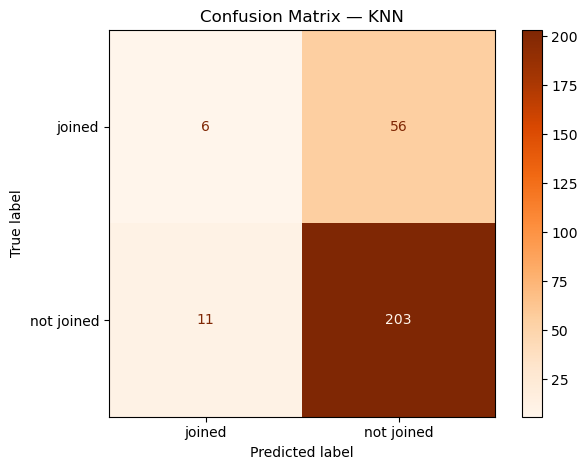

In [45]:
print("=== K-Nearest Neighbours ===")
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_knn, target_names=le_target.classes_))

cm_knn = confusion_matrix(y_test_enc, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=le_target.classes_)
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix — KNN')
plt.tight_layout()
plt.show()

#### 4. Logistic Regression

=== Logistic Regression ===
Accuracy : 0.7754

Classification Report:
              precision    recall  f1-score   support

      joined       0.00      0.00      0.00        62
  not joined       0.78      1.00      0.87       214

    accuracy                           0.78       276
   macro avg       0.39      0.50      0.44       276
weighted avg       0.60      0.78      0.68       276



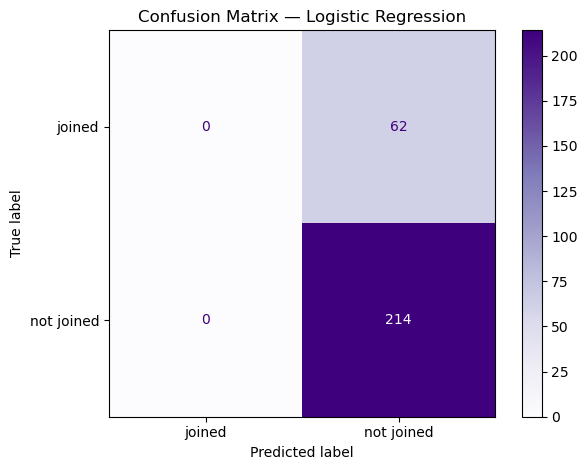

In [48]:
print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test_enc, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_lr, target_names=le_target.classes_))

cm_lr = confusion_matrix(y_test_enc, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le_target.classes_)
disp.plot(cmap='Purples')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

### Comparison of Model Accuracies

In [51]:
results = {
    'Decision Tree'      : accuracy_score(y_test_enc, y_pred_dt),
    'Random Forest'      : accuracy_score(y_test_enc, y_pred_rf),
    'KNN'                : accuracy_score(y_test_enc, y_pred_knn),
    'Logistic Regression': accuracy_score(y_test_enc, y_pred_lr)
}

results_df = pd.DataFrame(
    list(results.items()),
    columns=['Model', 'Accuracy']
).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results_df['Accuracy (%)'] = (results_df['Accuracy'] * 100).round(2)
print(results_df.to_string(index=False))

              Model  Accuracy  Accuracy (%)
Logistic Regression  0.775362         77.54
      Random Forest  0.768116         76.81
                KNN  0.757246         75.72
      Decision Tree  0.666667         66.67


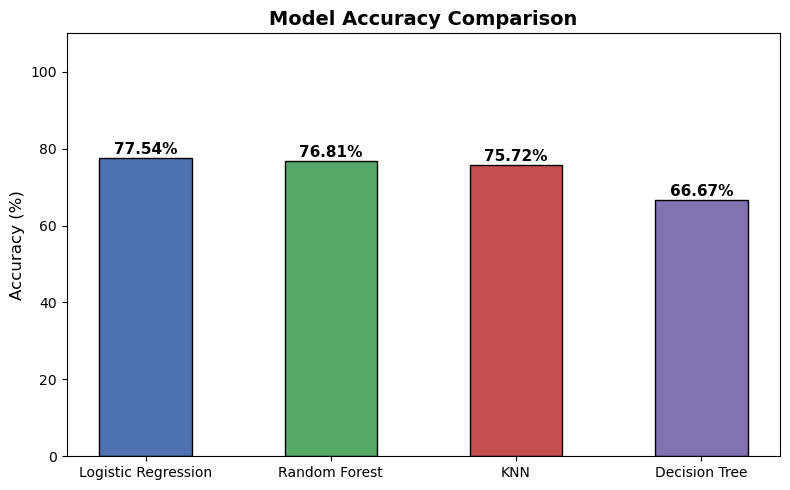

In [53]:
# Bar chart comparison
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Accuracy (%)'], color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, results_df['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{val:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 110)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

### Finalising the Best Model

Best Model  : Logistic Regression
Accuracy    : 77.54%
Requires Scaling: True


### Prediction on New Data

In [82]:
# -------------------------------------------------------
# Fill in the new enquiry details here
# -------------------------------------------------------
new_data = pd.DataFrame([{
    'location'        : 'kozhikode',        # replace with actual value
    'find_us'         : 'social media', # replace with actual value
    'qualification'   : 'ug',       # replace with actual value
    'branch'          : 'computer science',          # replace with actual value
    'career_issue'    : 'career gap',       # replace with actual value
    'looking_for'     : 'work experience',          # replace with actual value
    'technology'      : 'python',       # replace with actual value
    'mode'            : 'offline',      # replace with actual value
    'time_slot'       : 'morning',      # replace with actual value
    'attended_by'     : 'baiju', # replace with actual value
    'year_of_pass_out': 2022            # replace with actual value
}])

# -------------------------------------------------------
# Encode categorical columns using saved encoders
# -------------------------------------------------------
new_data_enc = new_data.copy()

for col in categorical_cols:
    le = label_encoders[col]
    new_data_enc[col] = le.transform(new_data_enc[col])

# -------------------------------------------------------
# Scale if required by the best model
# -------------------------------------------------------
if needs_scaling:
    new_data_input = scaler.transform(new_data_enc)
else:
    new_data_input = new_data_enc

# -------------------------------------------------------
# Predict
# -------------------------------------------------------
prediction_enc   = best_model.predict(new_data_input)
prediction_label = le_target.inverse_transform(prediction_enc)

print(f"Model Used  : {best_model_name}")
print(f"Prediction  : {prediction_label[0]}")

Model Used  : Logistic Regression
Prediction  : not joined


In [74]:
y.unique()

array(['not joined', 'joined'], dtype=object)